In [2]:
import json
import numpy as np
import pandas as pd
import scipy.signal as sig
import h5py
import os 
import matplotlib.pyplot as plt

In [3]:
from wsl_permission_manager import grant_universal_read_write_access, grant_universal_directory_access, set_path_permissions

# Your WSL path (make sure this is correct, including any spaces!)
# For a specific file like 'classes-fixed.json':
my_wsl_file_path_classes = r"\\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2\classes-fixed.json"
my_wsl_file_path_dataset = r"\\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2\GOLD_XYZ_OSC.0001_1024.hdf5"

# For the directory containing it:
my_wsl_directory_path = r"\\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2"

# --- Option 1: Grant rw-rw-rw- (0o666) to a specific file ---
print(f"Setting permissions for file: {my_wsl_file_path_classes}")
success_file = grant_universal_read_write_access(my_wsl_file_path_classes)
if success_file:
    print(f"Successfully granted read/write access to: {my_wsl_file_path_classes}")
    # Now try your file operation again
    # with open(my_wsl_file_path_classes, 'r') as f:
    #     content = f.read() # Or json.load(f)
    #     print("Successfully read file after permission change.")
else:
    print(f"Failed to set permissions for: {my_wsl_file_path_classes}")

print("-" * 30)

# --- Option 2: Grant rwxrwxrwx (0o777) to a directory ---
# (Use this if you need to list, create, or delete files within this directory)
print(f"Setting permissions for directory: {my_wsl_directory_path}")
success_dir = grant_universal_directory_access(my_wsl_directory_path)
if success_dir:
    print(f"Successfully granted full access to directory: {my_wsl_directory_path}")
    # import os
    # print(os.listdir(my_wsl_directory_path))
else:
    print(f"Failed to set permissions for directory: {my_wsl_directory_path}")

print("-" * 30)

Setting permissions for file: \\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2\classes-fixed.json
Attempting to set permissions for: '\\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2\classes-fixed.json' to 0o666
Successfully set permissions for '\\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2\classes-fixed.json' to 0o666.
Successfully granted read/write access to: \\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2\classes-fixed.json
------------------------------
Setting permissions for directory: \\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2
Attempting to set permissions for: '\\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2' to 0o777
Successfully set permissions for '\\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2' to 0o777.
Successfully granted full access to directory: \\wsl.localhost\Ubuntu\home\lipplopp\dataset_

In [4]:
X_arr = None
Y_arr = None # Inisialisasi variabel
Z_arr = None # Inisialisasi variabel

# Sel 2: Membuka file HDF5 dan membaca data
print(f"Mencoba membuka file: {my_wsl_file_path_dataset}")
if not os.path.exists(my_wsl_file_path_dataset):
    print(f"Error: File tidak ditemukan di {my_wsl_file_path_dataset}")
else:
    try:
        # Menggunakan locking=False langsung di sini
        with h5py.File(my_wsl_file_path_dataset, 'r', locking=False) as f:
            print("File HDF5 berhasil dibuka (tanpa penguncian).")
            Y_arr = f['Y'][:]            # shape (2555904, 24) jika mengikuti error awalmu
            Z_arr = f['Z'][:].flatten()  # shape (2555904,) jika mengikuti error awalmu
            print("Data berhasil dibaca.")
            # Kamu bisa langsung memproses Y_arr dan Z_arr di sini atau di sel berikutnya
            
    except BlockingIOError as e:
        print(f"Masih terjadi BlockingIOError meskipun menggunakan locking=False: {e}")
        print("Ini bisa mengindikasikan masalah yang lebih dalam dengan akses file atau file itu sendiri.")
    except KeyError as e:
        print(f"Error: Dataset tidak ditemukan di file HDF5: {e}. Pastikan nama dataset ('Y' atau 'Z') sudah benar.")
    except Exception as e:
        print(f"Terjadi error tak terduga saat membuka atau membaca file HDF5: {e}")

# Sel 3 (Opsional): Bekerja dengan data yang sudah dibaca
if Y_arr is not None and Z_arr is not None:
    print("\nMemeriksa data yang sudah dibaca:")
    print(f"Bentuk Y_arr: {Y_arr.shape}")
    print(f"Bentuk Z_arr: {Z_arr.shape}")
    # Lakukan operasi lain dengan Y_arr dan Z_arr
else:
    print("\nData tidak berhasil dibaca, tidak ada yang bisa diproses.")

Mencoba membuka file: \\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2\GOLD_XYZ_OSC.0001_1024.hdf5
File HDF5 berhasil dibuka (tanpa penguncian).
Data berhasil dibaca.

Memeriksa data yang sudah dibaca:
Bentuk Y_arr: (2555904, 24)
Bentuk Z_arr: (2555904,)


In [5]:
with open(my_wsl_file_path_classes, 'r') as f:
    fixed_classes = json.load(f)

print(f"Found {len(fixed_classes)} modulations:\n", fixed_classes)

Found 24 modulations:
 ['OOK', '4ASK', '8ASK', 'BPSK', 'QPSK', '8PSK', '16PSK', '32PSK', '16APSK', '32APSK', '64APSK', '128APSK', '16QAM', '32QAM', '64QAM', '128QAM', '256QAM', 'AM-SSB-WC', 'AM-SSB-SC', 'AM-DSB-WC', 'AM-DSB-SC', 'FM', 'GMSK', 'OQPSK']


In [6]:
# Coba cek apakah file ada
if not os.path.exists(my_wsl_file_path_dataset):
    print(f"Error: File tidak ditemukan di {my_wsl_file_path_dataset}")
else:
    print(f"File ditemukan di {my_wsl_file_path_dataset}. Mencoba membuka...")
    try:
        with h5py.File(my_wsl_file_path_dataset, 'r', locking=False) as f:
            print("File berhasil dibuka!")
            #Baris kode asli kamu untuk membaca data
            Y_arr = f['Y'][:]
            Z_arr = f['Z'][:].flatten()
            print("Data Y_arr shape:", Y_arr.shape)
            print("Data Z_arr shape:", Z_arr.shape)
            print("Silakan uncomment baris untuk membaca data jika file berhasil dibuka.")
    except BlockingIOError as e:
        print(f"Masih terjadi BlockingIOError: {e}")
    except Exception as e:
        print(f"Terjadi error lain: {e}")

File ditemukan di \\wsl.localhost\Ubuntu\home\lipplopp\dataset_AMC \radioml2018\versions\2\GOLD_XYZ_OSC.0001_1024.hdf5. Mencoba membuka...
File berhasil dibuka!
Data Y_arr shape: (2555904, 24)
Data Z_arr shape: (2555904,)
Silakan uncomment baris untuk membaca data jika file berhasil dibuka.


In [7]:
unique_snrs = np.unique(Z_arr)
print("Available SNR levels (dB):", unique_snrs)

Available SNR levels (dB): [-20 -18 -16 -14 -12 -10  -8  -6  -4  -2   0   2   4   6   8  10  12  14
  16  18  20  22  24  26  28  30]


In [8]:
def find_modulation_snr_indices(mod_name, snr_level, classes_fixed, Y_arr, Z_arr):
    """
    Return an array of sample-indices where:
      - the one-hot in Y_arr matches mod_name
      - the corresponding Z_arr == snr_level
    """
    mod_idx = classes_fixed.index(mod_name)
    mask = (np.argmax(Y_arr, axis=1) == mod_idx) & (Z_arr == snr_level)
    return np.nonzero(mask)[0]

In [9]:
def plot_signals_by_modulation_snr(mod_name, snr_level, num_samples, file_path, classes_fixed, Y_arr, Z_arr):
    # 1) find indices
    idxs = find_modulation_snr_indices(mod_name, snr_level, classes_fixed, Y_arr, Z_arr)
    if len(idxs) < num_samples:
        print(f"⚠️ Only found {len(idxs)} samples for {mod_name}@{snr_level} dB")
        return

    # 2) pick a few at random
    chosen = np.random.choice(idxs, num_samples, replace=False)

    # 3) re-open HDF5 and slice X for each sample
    with h5py.File(file_path, 'r',locking=False) as f:
        X_ds = f['X']  # shape (N, 1024, 2)
        for samp in chosen:
            I = X_ds[samp, :, 0]
            Q = X_ds[samp, :, 1]
            M = np.sqrt(I**2 + Q**2)

            fig, axs = plt.subplots(1, 3, figsize=(15, 3))
            axs[0].plot(I); axs[0].set_title(f"{mod_name} I (SNR={snr_level}dB)")
            axs[1].plot(Q); axs[1].set_title(f"{mod_name} Q")
            axs[2].plot(M); axs[2].set_title("Magnitude")
            for ax in axs:
                ax.set_xlabel("Sample index")
            plt.tight_layout()
            plt.show()

In [10]:
with h5py.File(my_wsl_file_path_dataset, 'r', locking=False) as f:
    Y_onehot = f['Y'][:]    # one-hot label array, shape (N_samples, N_mods)
    Z_arr     = f['Z'][:].flatten()  # SNRs

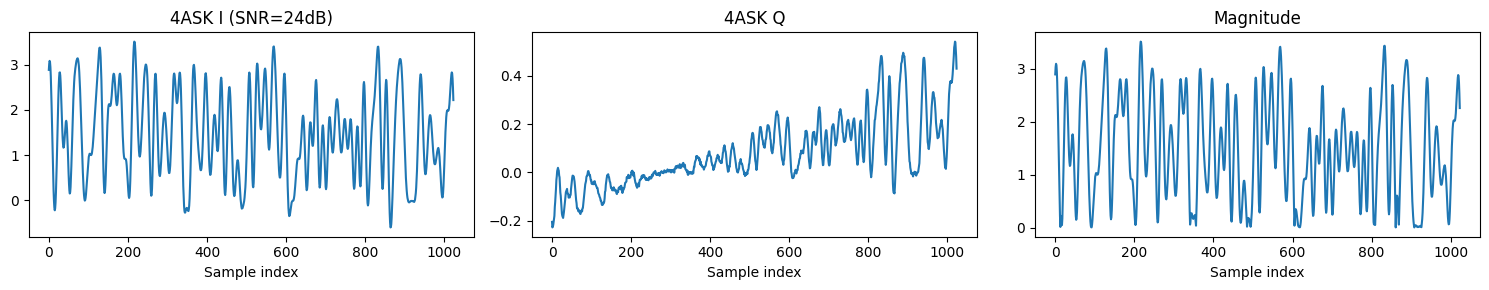

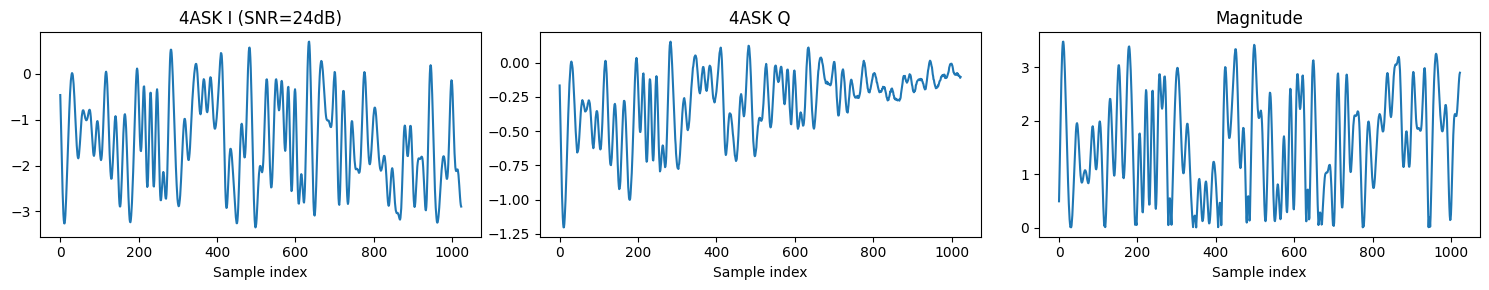

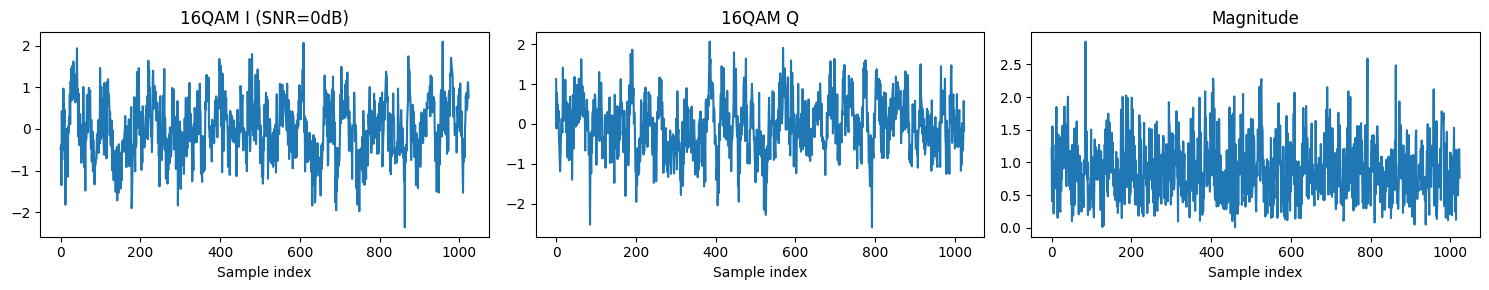

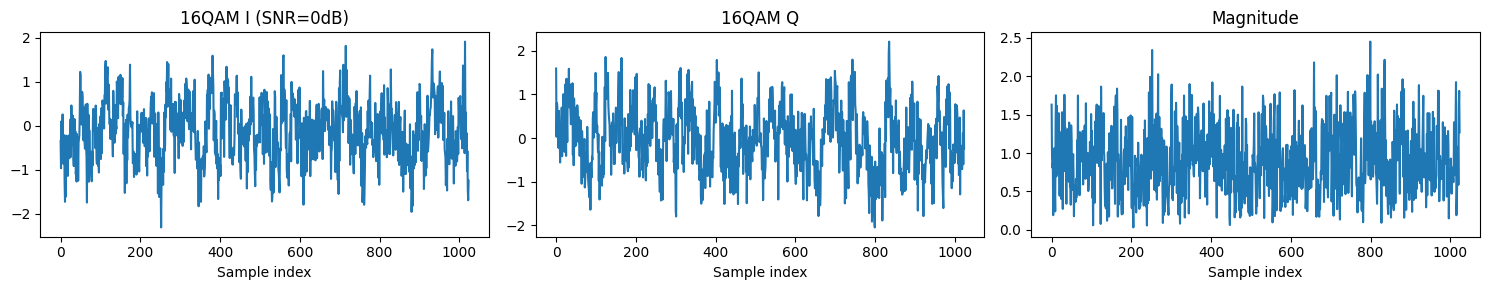

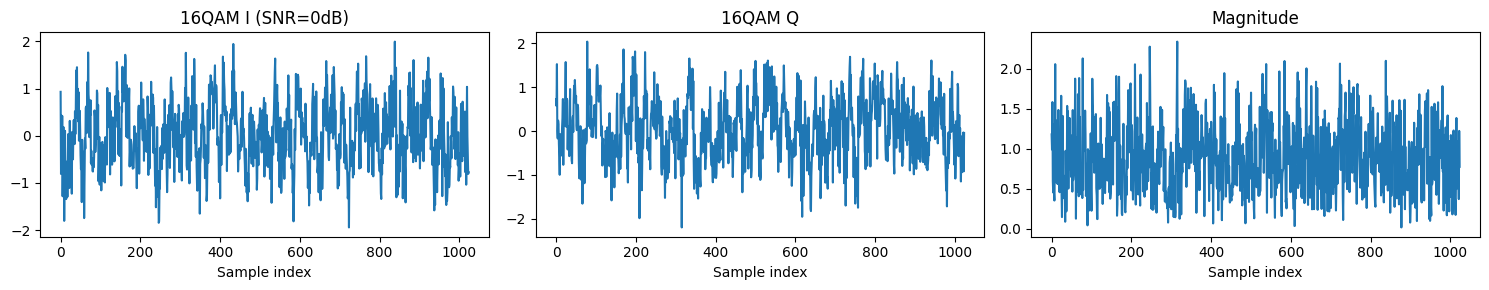

In [11]:
plot_signals_by_modulation_snr(
    mod_name='4ASK',
    snr_level=24,
    num_samples=2,
    file_path=my_wsl_file_path_dataset,
    classes_fixed=fixed_classes,
    Y_arr=Y_arr,
    Z_arr=Z_arr
)

# Plot 3 random 16QAM signals at 0 dB
plot_signals_by_modulation_snr(
    mod_name='16QAM',
    snr_level=0,
    num_samples=3,
    file_path=my_wsl_file_path_dataset,
    classes_fixed=fixed_classes,
    Y_arr=Y_arr,
    Z_arr=Z_arr
)

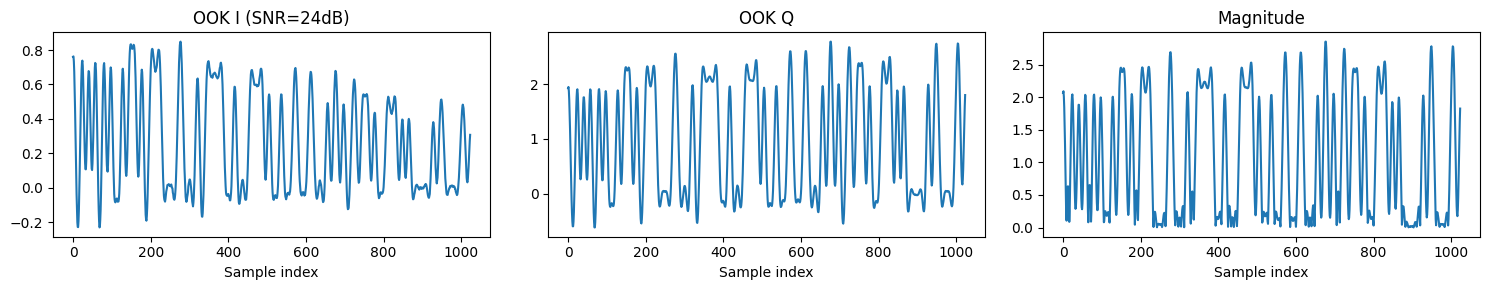

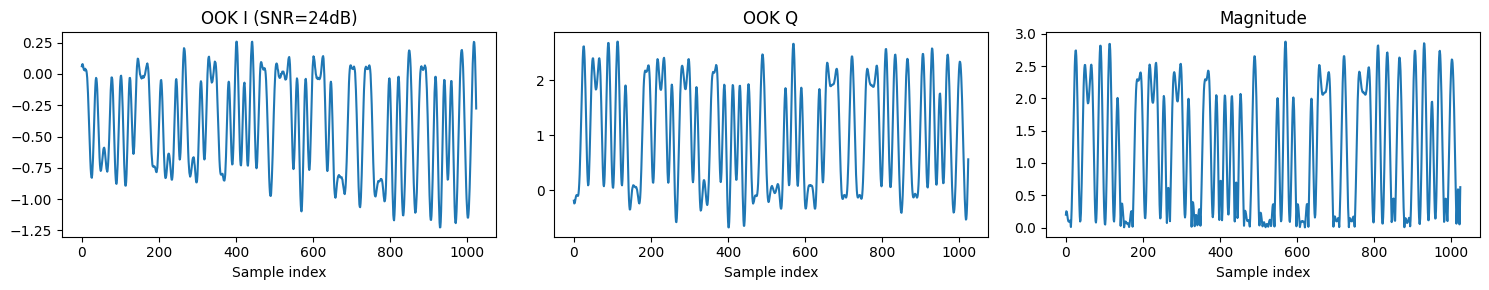

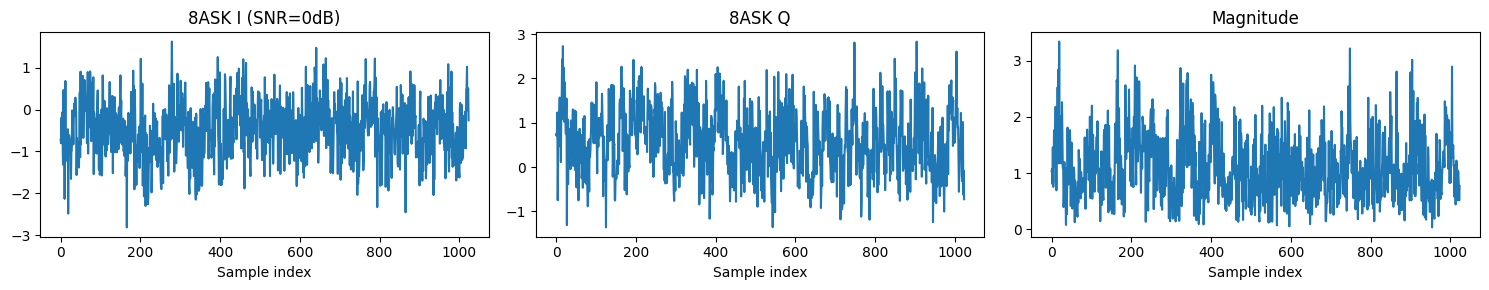

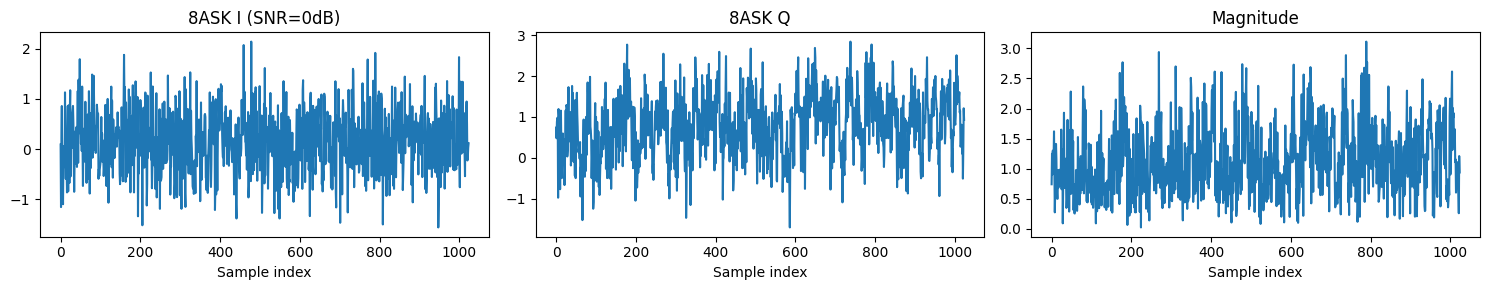

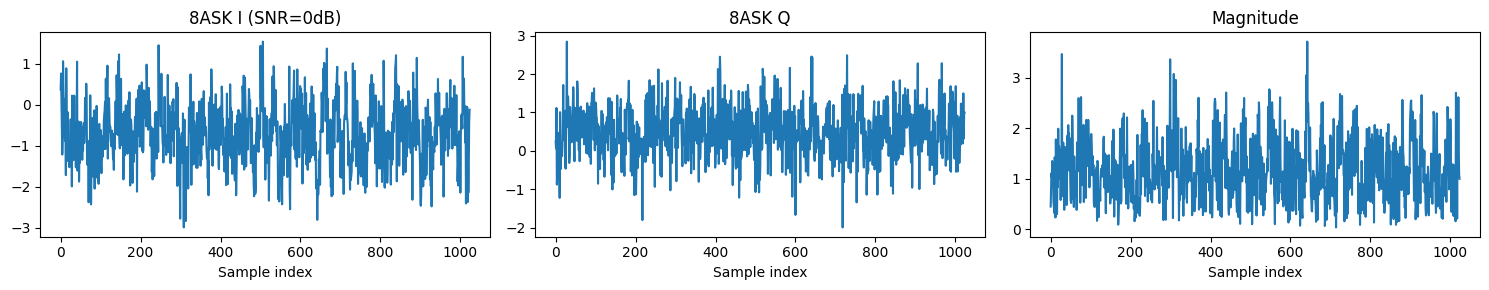

In [12]:
plot_signals_by_modulation_snr(
    mod_name='OOK',
    snr_level=24,
    num_samples=2,
    file_path=my_wsl_file_path_dataset,
    classes_fixed=fixed_classes,
    Y_arr=Y_arr,
    Z_arr=Z_arr
)

# Plot 3 random 16QAM signals at 0 dB
plot_signals_by_modulation_snr(
    mod_name='8ASK',
    snr_level=0,
    num_samples=3,
    file_path=my_wsl_file_path_dataset,
    classes_fixed=fixed_classes,
    Y_arr=Y_arr,
    Z_arr=Z_arr
)

### BPSK MODULATION 

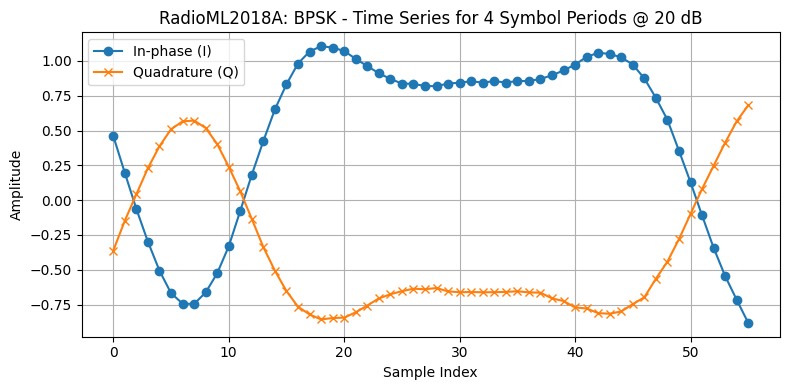

In [13]:
# --- Parameters ---
file_path = my_wsl_file_path_dataset   # Your HDF5 dataset path
modulation = 'BPSK'    # Any you like: 'BPSK', 'QPSK', '16QAM', etc.
snr_level = 20
samples_per_symbol = 14  # Typical, but check your dataset!
symbol_periods_to_plot = 4  # Number of symbol periods you want to visualize

# --- Helper to find sample index ---
idxs = find_modulation_snr_indices(modulation, snr_level, fixed_classes, Y_arr, Z_arr)
if len(idxs) == 0:
    raise ValueError("No sample found for this modulation/SNR combination.")
sample_idx = idxs[0]

# --- Load I/Q data for selected sample ---
with h5py.File(file_path, 'r',locking=False) as f:
    X_ds = f['X']
    sample = X_ds[sample_idx, :, :]  # shape: [N_samples, 2]
    I = sample[:, 0]
    Q = sample[:, 1]

# --- Choose a symbol boundary (for realistic symbol plotting, align to symbol start) ---
# Here, just pick the first symbol(s)
N = samples_per_symbol * symbol_periods_to_plot
I_period = I[:N]
Q_period = Q[:N]

# --- Plot ---
plt.figure(figsize=(8, 4))
plt.plot(I_period, label='In-phase (I)', marker='o')
plt.plot(Q_period, label='Quadrature (Q)', marker='x')
plt.title(f"RadioML2018A: {modulation} - Time Series for {symbol_periods_to_plot} Symbol Periods @ {snr_level} dB")
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_11940\4284786026.py:38: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_energy = np.trapz(energy_density)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_11940\4284786026.py:46: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  transition_energy = np.trapz(energy_density[transition_mask])


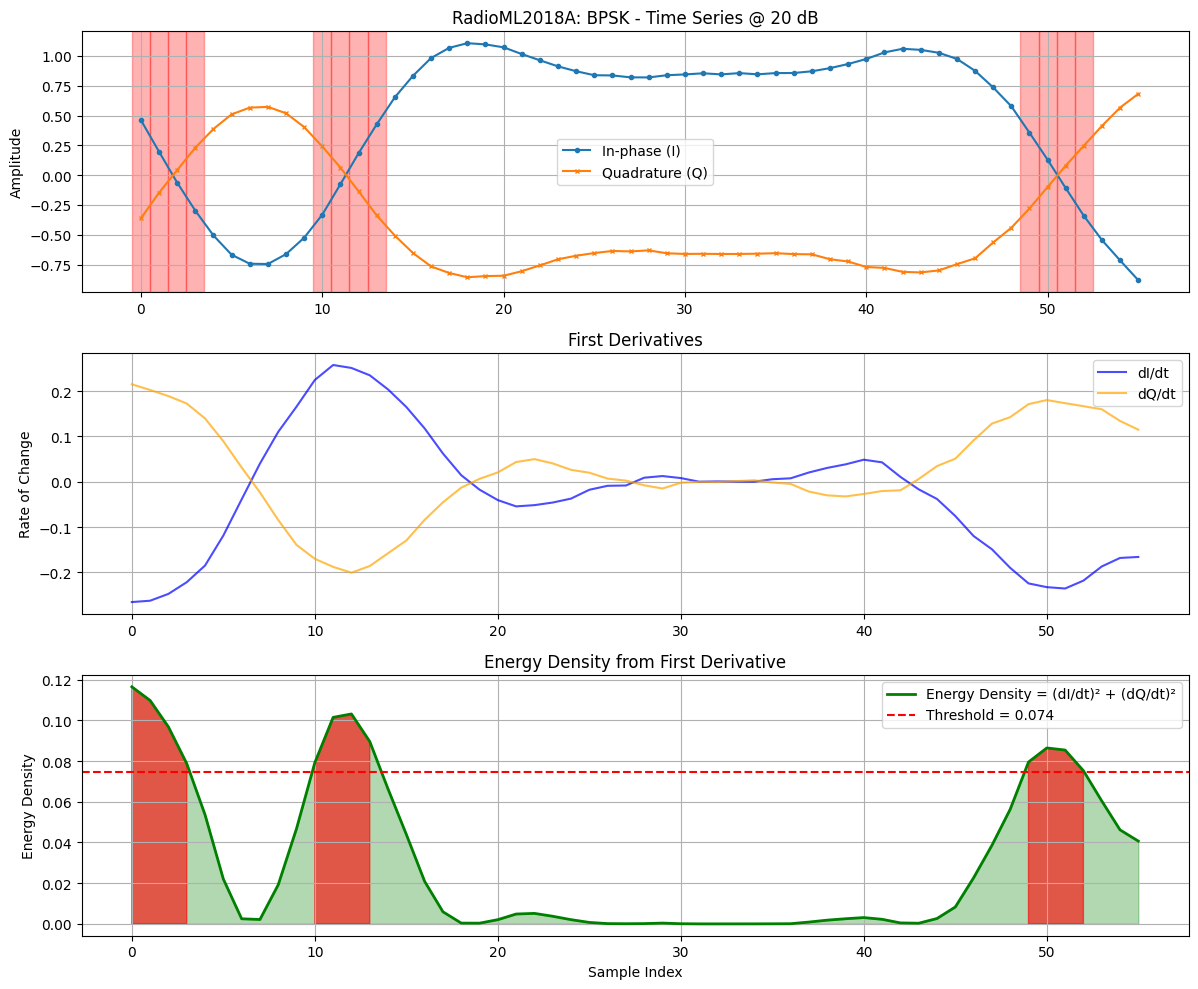

Total Energy: 1.614183
Transition Energy (from mask): 1.006065
Transition Energy Ratio (from mask): 62.33%

Manual Region Analysis (for 3 identified transitions):
Transition 1 Energy (samples 0-8): 0.433459
Transition 2 Energy (samples 10-16): 0.454534
Transition 3 Energy (samples 48-55): 0.481800

Energy per Symbol Period (using sps=14, analyzing 4 periods):
Symbol 1 Energy (samples 0-13): 0.818605
Symbol 2 Energy (samples 14-27): 0.123355
Symbol 3 Energy (samples 28-41): 0.010096
Symbol 4 Energy (samples 42-55): 0.582708
Average Energy per Symbol: 0.383691


C:\Users\ASUS\AppData\Local\Temp\ipykernel_11940\4284786026.py:118: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(region_energy_density)


In [14]:
# --- Parameters ---
file_path = my_wsl_file_path_dataset  # Your HDF5 dataset path
modulation = 'BPSK'  # Any you like: 'BPSK', 'QPSK', '16QAM', etc.
snr_level = 20
samples_per_symbol = 14  # Typical, but check your dataset!
symbol_periods_to_plot = 4  # Number of symbol periods you want to visualize

# --- Helper to find sample index ---
idxs = find_modulation_snr_indices(modulation, snr_level, fixed_classes, Y_arr, Z_arr)
if len(idxs) == 0:
    raise ValueError("No sample found for this modulation/SNR combination.")
sample_idx = idxs[0]

# --- Load I/Q data for selected sample ---
with h5py.File(file_path, 'r',locking = False) as f:

    X_ds = f['X']
    sample = X_ds[sample_idx, :, :]  # shape: [N_samples, 2]

I = sample[:, 0]
Q = sample[:, 1]

# --- Choose a symbol boundary ---
N = samples_per_symbol * symbol_periods_to_plot
I_period = I[:N]
Q_period = Q[:N]

# --- Calculate First Derivatives ---
# Using numpy gradient for numerical differentiation
dI_dt = np.gradient(I_period)
dQ_dt = np.gradient(Q_period)

# --- Calculate Energy using First Derivative ---
# Energy = integral of (dI/dt)^2 + (dQ/dt)^2
energy_density = dI_dt**2 + dQ_dt**2

# Total energy over the entire period
total_energy = np.trapz(energy_density)

# --- Identify Transition Regions (Shifting areas) ---
# You can define thresholds based on derivative magnitude
threshold = np.std(energy_density) * 2  # Adjust this multiplier as needed
transition_mask = energy_density > threshold

# Calculate energy only in transition regions
transition_energy = np.trapz(energy_density[transition_mask])

# --- Plotting ---
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10))

# Plot 1: Original I/Q signals
ax1.plot(I_period, label='In-phase (I)', marker='o', markersize=3)
ax1.plot(Q_period, label='Quadrature (Q)', marker='x', markersize=3)
ax1.set_title(f"RadioML2018A: {modulation} - Time Series @ {snr_level} dB")
ax1.set_ylabel('Amplitude')
ax1.grid(True)
ax1.legend()

# Highlight transition regions
for i in range(len(transition_mask)):
    if transition_mask[i]:
        ax1.axvspan(i-0.5, i+0.5, alpha=0.3, color='red')

# Plot 2: First derivatives
ax2.plot(dI_dt, label='dI/dt', color='blue', alpha=0.7)
ax2.plot(dQ_dt, label='dQ/dt', color='orange', alpha=0.7)
ax2.set_title('First Derivatives')
ax2.set_ylabel('Rate of Change')
ax2.grid(True)
ax2.legend()

# Plot 3: Energy density
ax3.plot(energy_density, label='Energy Density = (dI/dt)² + (dQ/dt)²', color='green', linewidth=2)
ax3.fill_between(range(len(energy_density)), energy_density, alpha=0.3, color='green')
ax3.axhline(y=threshold, color='red', linestyle='--', label=f'Threshold = {threshold:.3f}')
ax3.set_title('Energy Density from First Derivative')
ax3.set_xlabel('Sample Index')
ax3.set_ylabel('Energy Density')
ax3.grid(True)
ax3.legend()

# Highlight high-energy transition regions
ax3.fill_between(range(len(energy_density)), energy_density,
                where=transition_mask, alpha=0.6, color='red',
                label='Transition Regions')

plt.tight_layout()
plt.show()

# --- Print Results (Existing part from your snippet) ---
# Ensure these variables are defined and calculated based on the data from image_f5cf78.png
if 'total_energy' in locals() or 'total_energy' in globals():
    print(f"Total Energy: {total_energy:.6f}")
    if 'transition_energy' in locals() or 'transition_energy' in globals():
        print(f"Transition Energy (from mask): {transition_energy:.6f}")
        if total_energy != 0:
            print(f"Transition Energy Ratio (from mask): {transition_energy/total_energy:.2%}")
        else:
            print("Transition Energy Ratio (from mask): Total energy is zero, ratio undefined.")
    else:
        print("Warning: 'transition_energy' (from mask) not defined.")
else:
    print("Warning: 'total_energy' not defined.")


# --- Function to calculate energy in a specific region ---
def calculate_region_energy(start_idx, end_idx, energy_density_array):
    """Calculate energy in a specific region from the given energy_density_array"""
    # Ensure indices are within bounds
    start_idx = max(0, start_idx)
    end_idx = min(len(energy_density_array) - 1, end_idx)

    if start_idx > end_idx:
        print(f"Warning: Invalid range for energy calculation (start_idx={start_idx}, end_idx={end_idx}). Returning 0.")
        return 0.0

    region_energy_density = energy_density_array[start_idx:end_idx+1]
    return np.trapz(region_energy_density)

# --- MODIFIED: Manual Integration for Specific Regions identified from image_f5cf78.png ---
print(f"\nManual Region Analysis (for 3 identified transitions):")

# Define the start and end indices for the 3 transitions
# (based on image_f5cf78.png, x-axis up to ~56, Threshold = 0.074)
identified_transitions_from_image_f5cf78 = [
    {"label": "Transition 1", "start": 0, "end": 8},
    {"label": "Transition 2", "start": 10, "end": 16},
    {"label": "Transition 3", "start": 48, "end": 55},
]

# Ensure energy_density is defined and populated before this loop
if 'energy_density' in locals() or 'energy_density' in globals():
    if len(energy_density) > 0: # Check if energy_density is not empty
        for transition in identified_transitions_from_image_f5cf78:
            current_transition_energy = calculate_region_energy(
                transition["start"],
                transition["end"],
                energy_density
            )
            print(f"{transition['label']} Energy (samples {transition['start']}-{transition['end']}): {current_transition_energy:.6f}")
    else:
        print("Warning: 'energy_density' array is empty. Cannot perform manual region analysis.")
else:
    print("Warning: 'energy_density' variable is not defined. Cannot perform manual region analysis.")

# --- Energy per Symbol Period (Existing part from your snippet, with robustness) ---
# This section assumes 'samples_per_symbol' and 'symbol_periods_to_plot'
# are appropriately set for the 'energy_density' array from image_f5cf78.png.
# For image_f5cf78.png, N is ~56. If sps=14, then symbol_periods_to_plot would be 4.

if ('energy_density' in locals() or 'energy_density' in globals()) and \
   ('samples_per_symbol' in locals() or 'samples_per_symbol' in globals()):
    if len(energy_density) > 0 and samples_per_symbol > 0:
        actual_symbol_periods = len(energy_density) // samples_per_symbol

        # Use 'symbol_periods_to_plot' if defined and valid, otherwise use actual_symbol_periods
        num_periods_to_analyze = symbol_periods_to_plot \
            if ('symbol_periods_to_plot' in locals() or 'symbol_periods_to_plot' in globals()) \
               and symbol_periods_to_plot <= actual_symbol_periods \
            else actual_symbol_periods

        print(f"\nEnergy per Symbol Period (using sps={samples_per_symbol}, analyzing {num_periods_to_analyze} periods):")
        energy_per_symbol_list = [] # Renamed to avoid conflict if 'energy_per_symbol' var is used elsewhere

        for symbol_idx in range(num_periods_to_analyze):
            start_idx = symbol_idx * samples_per_symbol
            end_idx = (symbol_idx + 1) * samples_per_symbol - 1

            symbol_energy = calculate_region_energy(start_idx, end_idx, energy_density)
            energy_per_symbol_list.append(symbol_energy)
            print(f"Symbol {symbol_idx+1} Energy (samples {start_idx}-{end_idx}): {symbol_energy:.6f}")

        if energy_per_symbol_list:
            print(f"Average Energy per Symbol: {np.mean(energy_per_symbol_list):.6f}")
        else:
            print("No symbol periods to analyze for energy per symbol.")
    else:
        print("Warning: 'energy_density' is empty or 'samples_per_symbol' is zero. Cannot calculate energy per symbol period.")
else:
    print("Warning: 'energy_density' or 'samples_per_symbol' not defined. Cannot calculate energy per symbol period.")

In [15]:
# assuming I_period, Q_period, samples_per_symbol, symbol_periods_to_plot defined

e = I_period**2 + Q_period**2
M = samples_per_symbol
P = symbol_periods_to_plot

# symbol‐by‐symbol energies
sym_E = np.array([ e[k*M:(k+1)*M].sum() for k in range(P) ])
total_E = sym_E.sum()

# transition regions (you can pick k=0 boundary and k=P-1 boundary)
t1 = e[8:13].sum()
t2 = e[48:53].sum()
trans_E = t1 + t2
trans_ratio = 100 * trans_E / total_E

print(f"Total Energy:           {total_E:.6f}")
print(f"Transition Energy:      {trans_E:.6f}")
print(f"Transition Energy Ratio:{trans_ratio:.2f}%\n")

for i, Ei in enumerate(sym_E, start=1):
    print(f"Symbol {i} Energy:      {Ei:.6f}")
print(f"Average Energy/symbol:  {sym_E.mean():.6f}")

Total Energy:           54.816658
Transition Energy:      2.332405
Transition Energy Ratio:4.25%

Symbol 1 Energy:      5.091459
Symbol 2 Energy:      19.944223
Symbol 3 Energy:      17.421299
Symbol 4 Energy:      12.359678
Average Energy/symbol:  13.704165


Detected symbol‐boundary sample indices: [501 989]


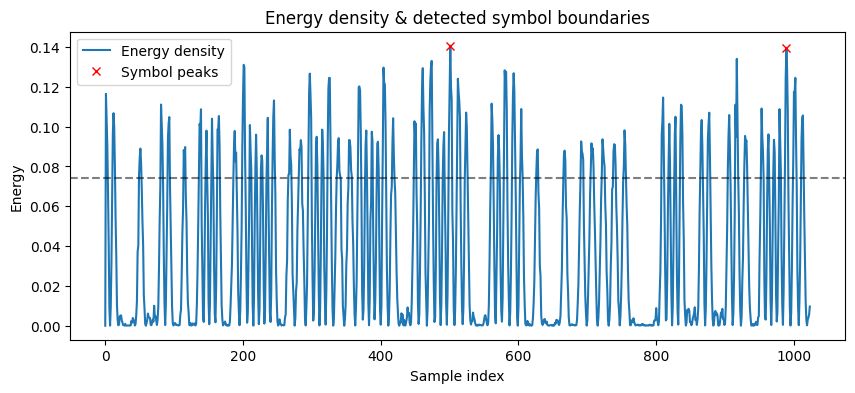

In [16]:
# helper (re-use your energy density code up through region detection)
def compute_energy_density(I, Q):
    dI = np.diff(I, prepend=I[0])
    dQ = np.diff(Q, prepend=Q[0])
    return dI**2 + dQ**2

def detect_symbol_boundaries(energy, n_peaks=2, distance=None, height=None):
    # find local maxima in the energy-density curve
    peaks, props = sig.find_peaks(energy, distance=distance, height=height)
    # sort by peak height descending and return top n_peaks indices
    top = peaks[np.argsort(props['peak_heights'])[::-1][:n_peaks]]
    return np.sort(top)

# --- load a single sample's I/Q at 20dB from your HDF5 ---
file_path = my_wsl_file_path_dataset
modulation  = 'BPSK'
snr_level   = 20

idxs = find_modulation_snr_indices(modulation, snr_level, fixed_classes, Y_arr, Z_arr)
sample_idx = idxs[0]

with h5py.File(file_path,'r',locking = False) as f:
    X = f['X'][sample_idx]  # shape (1024,2)
    I, Q = X[:,0], X[:,1]

# --- compute energy density ---
energy = compute_energy_density(I, Q)

# --- find the two main transition peaks ---
# require peaks at least samples_per_symbol apart
distance = samples_per_symbol - 2  
boundaries = detect_symbol_boundaries(energy, n_peaks=2,
                                      distance=distance,
                                      height=np.percentile(energy,75))

print("Detected symbol‐boundary sample indices:", boundaries)

# --- plot to verify ---
plt.figure(figsize=(10,4))
plt.plot(energy, label='Energy density')
plt.plot(boundaries, energy[boundaries], 'rx', label='Symbol peaks')
plt.axhline(np.percentile(energy,75), color='k', linestyle='--', alpha=0.5)
plt.legend(); plt.title("Energy density & detected symbol boundaries")
plt.xlabel("Sample index"); plt.ylabel("Energy")
plt.show()


Symbol center sample indices: [508 522 536 550 564 578 592 606 620 634 648 662 676 690 704 718 732 746
 760 774 788 802 816 830 844 858 872 886 900 914 928 942 956 970]


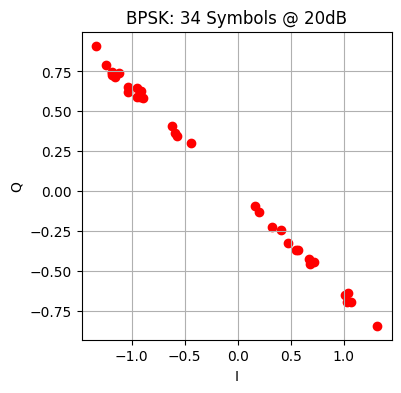

In [17]:
# --- assume we already have these from the previous step ---
# I, Q        : full time‐series length Nsamples (e.g. 1024)
# boundaries  : sorted array of two transition indices, e.g. [ 10, 50 ]
# samples_per_symbol = 14

# total symbols across these two transitions = (bound2 - bound1) / samples_per_symbol
num_symbols = int((boundaries[1] - boundaries[0]) / samples_per_symbol)

# compute the center offset
half_sp = samples_per_symbol // 2

# generate all symbol mid‐points between the two peaks
symbol_centers = boundaries[0] + half_sp + np.arange(0, num_symbols) * samples_per_symbol
symbol_centers = symbol_centers.astype(int)

print("Symbol center sample indices:", symbol_centers)

# pull out one I/Q per symbol
I_sym = I[symbol_centers]
Q_sym = Q[symbol_centers]

# (Optionally) plot these points on your constellation:
plt.figure(figsize=(4,4))
plt.scatter(I_sym, Q_sym, c='r', marker='o')
plt.title(f"{modulation}: {num_symbols} Symbols @ {snr_level}dB")
plt.xlabel("I"); plt.ylabel("Q"); plt.grid(True)
plt.show()


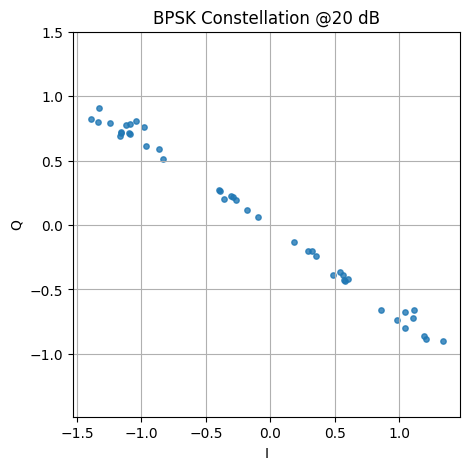

In [18]:
N = len(I)                     # e.g. 1024
sps = 24                   # samples per symbol in RadioML2018.01A
symbol_centers = np.arange(sps//2, N, sps, dtype=int)

# now pick those samples
I_pts = I[symbol_centers]
Q_pts = Q[symbol_centers]

# constellation scatter
plt.figure(figsize=(5,5))
plt.scatter(I_pts, Q_pts, s=15, alpha=0.8)
plt.title(f"BPSK Constellation @{snr_level} dB")
plt.xlabel("I"); plt.ylabel("Q")
plt.grid(True)
plt.axis("equal")
plt.show()

c:\Users\ASUS\.conda\envs\dl-env\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\ASUS\.conda\envs\dl-env\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\ASUS\.conda\envs\dl-env\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ASUS\.conda\envs\dl-env\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\ASUS\.conda\envs\dl-env\Lib\subprocess.py", line 1538, in _execute_child


Estimasi Titik Pusat BPSK:
Pusat 1: I=0.7582, Q=-0.5315
Pusat 2: I=-0.8402, Q=0.5524


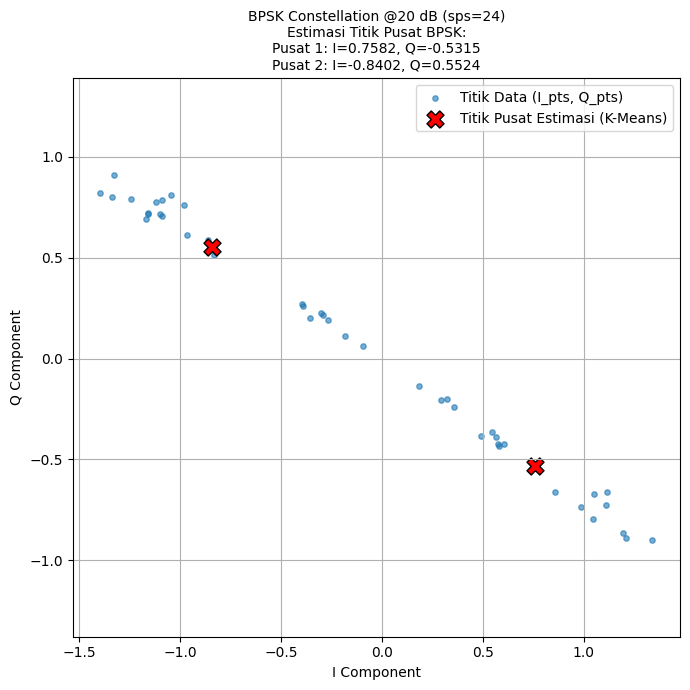

In [19]:
from sklearn.cluster import KMeans
N = len(I)
sps = 24 # Pengaturan sps Anda saat ini

# Logika untuk menentukan symbol_centers berdasarkan sps
if sps == 1:
    # Jika sps adalah 1, kita anggap setiap sampel adalah sebuah simbol.
    # Ini berarti I_pts akan menjadi I, dan Q_pts akan menjadi Q.
    symbol_centers = np.arange(N, dtype=int)
else:
    # Logika downsampling jika sps > 1 (mengambil sampel di tengah durasi simbol)
    # Pastikan N cukup besar untuk logika ini
    if N > sps//2 : # Perlu setidaknya satu titik pusat potensial
        symbol_centers = np.arange(sps//2, N, sps, dtype=int)
    else:
        symbol_centers = np.array([], dtype=int) # Kosong jika N terlalu kecil

# Pastikan symbol_centers tidak kosong sebelum mengambil sampel
if len(symbol_centers) > 0:
    I_pts = I[symbol_centers]
    Q_pts = Q[symbol_centers]
else:
    print(f"Peringatan: Tidak ada 'symbol_centers' yang ditemukan dengan N={N} dan sps={sps}.")
    print("Memplot semua titik I, Q jika memungkinkan, atau tidak ada titik jika I, Q kosong.")
    I_pts = I # Fallback ke semua titik jika symbol_centers kosong tapi I/Q ada
    Q_pts = Q

# --- Modifikasi untuk menemukan titik pusat menggunakan K-Means ---
center_points = None # Inisialisasi
estimated_centers_text = "Tidak ada titik pusat yang diestimasi."

# K-Means memerlukan setidaknya sejumlah sampel yang sama dengan jumlah klaster
if len(I_pts) >= 2: # Untuk n_clusters=2, kita butuh setidaknya 2 titik
    # Gabungkan I_pts dan Q_pts menjadi satu array untuk K-Means
    # Bentuknya harus (n_samples, n_features), di mana n_features=2 (I dan Q)
    points_for_clustering = np.vstack((I_pts, Q_pts)).T

    # Inisialisasi K-Means dengan 2 klaster (karena BPSK memiliki 2 titik konstelasi)
    # random_state untuk reproduktifitas, n_init='auto' untuk menekan warning
    kmeans = KMeans(n_clusters=2, random_state=0, n_init='auto')

    # Lakukan clustering pada titik-titik (I_pts, Q_pts)
    kmeans.fit(points_for_clustering)

    # Dapatkan koordinat titik pusat klaster yang ditemukan
    center_points = kmeans.cluster_centers_
    # center_points akan menjadi array [[I_center1, Q_center1], [I_center2, Q_center2]]

    estimated_centers_text = (
        f"Estimasi Titik Pusat BPSK:\n"
        f"Pusat 1: I={center_points[0,0]:.4f}, Q={center_points[0,1]:.4f}\n"
        f"Pusat 2: I={center_points[1,0]:.4f}, Q={center_points[1,1]:.4f}"
    )
    print(estimated_centers_text)
else:
    print("Tidak cukup titik data (I_pts) untuk melakukan clustering K-Means (dibutuhkan minimal 2).")
# --- Akhir Modifikasi ---

# Visualisasi konstelasi
plt.figure(figsize=(7,7)) # Ukuran disesuaikan agar legenda dan judul muat
plt.scatter(I_pts, Q_pts, s=15, alpha=0.6, label='Titik Data (I_pts, Q_pts)')

# Plot titik pusat estimasi jika ditemukan
if center_points is not None:
    plt.scatter(center_points[:,0], center_points[:,1], s=150, c='red', marker='X', edgecolor='black', label='Titik Pusat Estimasi (K-Means)')

plt.title(f"BPSK Constellation @{snr_level} dB (sps={sps})\n{estimated_centers_text}", fontsize=10)
plt.xlabel("I Component")
plt.ylabel("Q Component")
plt.grid(True)
plt.axis("equal")
plt.legend()
plt.tight_layout() # Menyesuaikan layout agar semua elemen terlihat baik
plt.show()
